<a href="https://colab.research.google.com/github/chanxxw/AI_Medical_Practice/blob/main/ISIC2016_Lesion_Classification_CNN_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# 필요한 패키지 설치 (transformers 라이브러리)
import subprocess

# pip3 명령어를 파이썬 코드로 실행
subprocess.check_call(["pip3", "install", "-q", "-U", "transformers==4.38.1"])


0

### 데이터 관련
1. https://challenge.isic-archive.com/data/ 에서 3번 데이터 4개 다운
2. 구글드라이브 최상위 위치에 ISIC2016 폴더를 만들어 다운받은 4개를 업로드.

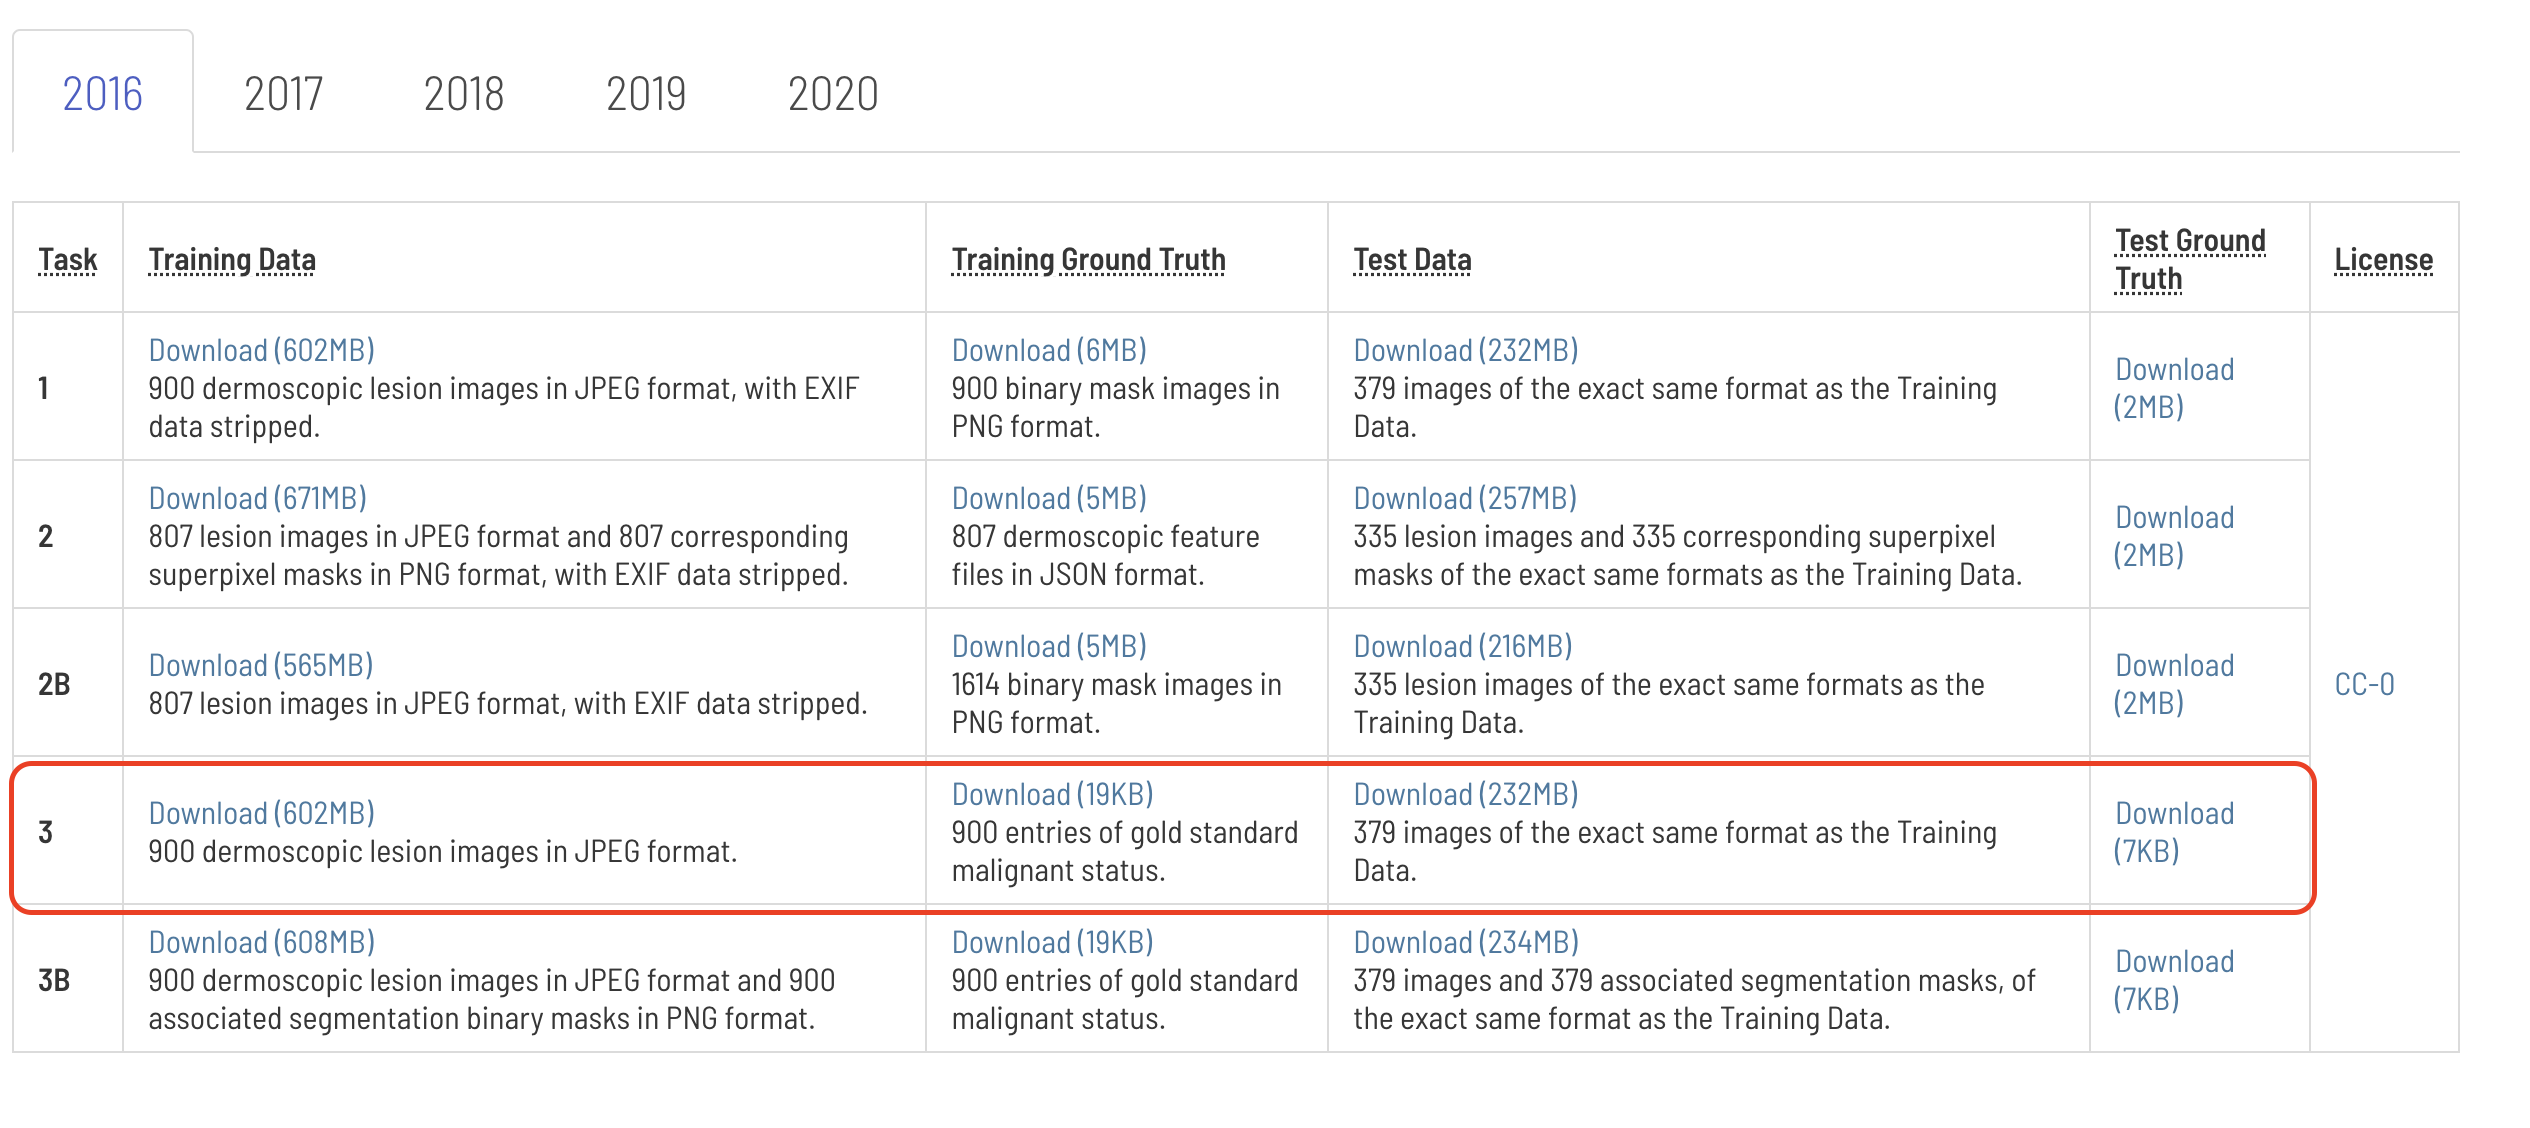

In [8]:
# Google Drive 연동을 위한 라이브러리
from google.colab import drive

# google drive 연결
drive.mount('/content/drive')

# 데이터셋 경로 설정  (Colab에서 내 구글 드라이브 접근 가능하도록 설정)
data_dir = '/content/drive/MyDrive/ISIC2016'
tr_path = data_dir + '/ISBI2016_ISIC_Part3_Training_Data.zip'
ts_path = data_dir + '/ISBI2016_ISIC_Part3_Test_Data.zip'

# zip 파일 압축 해제
!unzip -q {tr_path} -d {data_dir}
!unzip -q {ts_path} -d {data_dir}

# zip 파일 삭제
!rm {tr_path}
!rm {ts_path}

# 한번 작업하면 zip 파일이 삭제될 것이기에 추가로 돌리는 경우 zip이 풀리지는 않을 것

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
unzip:  cannot find or open /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_Data.zip, /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_Data.zip.zip or /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_Data.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_Data.zip, /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_Data.zip.zip or /content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_Data.zip.ZIP.
rm: cannot remove '/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_Data.zip': No such file or directory
rm: cannot remove '/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_Data.zip': No such file or directory


In [11]:
# ISIC Dataset 정의
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image #PIL : 이미지를 읽어주는 라이브러리
import os
import pandas as pd

# ISIC Dataset 정의 (CSV의 이미지 파일명과 라벨을 이용)

class ISICDataset(Dataset):
  def __init__(self, csv_file, root_dir, transform=None):
    self.annotations = pd.read_csv(csv_file)  # CSV 파일 로드
    self.root_dir = root_dir                  # 이미지 디렉터리 경로
    self.transform = transform                # transform 함수 저장

  def __len__(self):
    return len(self.annotations)              # 전체 샘플 수 반환

  def __getitem__(self, idx):
    # 이미지 경로 구성
    img_name = os.path.join(self.root_dir, self.annotations.iloc[idx, 0] + '.jpg')
    image = Image.open(img_name)
    label = self.annotations.iloc[idx, 1] # 라벨을 숫자가 아닌 문자열로 받아옵니다.

    if self.transform:
      image = self.transform(image)

    return image, label

# ---- 이미지 전처리 ----

# 이미지 변환 정의: 크기 조정, 텐서 변환, 정규화
transform = transforms.Compose([
  transforms.Resize((128, 128)), # 이미지 크기 조정, 28x28은 의료데이터에서는 터무니 없이 작은 값이라서 128정도로 구성
  transforms.ToTensor(), # 이미지를 텐서로 변환
  transforms.Normalize((0.5,), (0.5,)) # 정규화
])

# 데이터셋 및 데이터로더 생성
tr_ds = ISICDataset(csv_file=os.path.join(data_dir, 'ISBI2016_ISIC_Part3_Training_GroundTruth.csv'),
                    root_dir=os.path.join(data_dir, 'ISBI2016_ISIC_Part3_Training_Data'),
                    transform=transform)

ts_ds = ISICDataset(csv_file=os.path.join(data_dir, 'ISBI2016_ISIC_Part3_Test_GroundTruth.csv'),
                    root_dir=os.path.join(data_dir, 'ISBI2016_ISIC_Part3_Test_Data'),
                    transform=transform)

tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True) # 가급적 섞어주는 것이 좋음
ts_loader = DataLoader(ts_ds, batch_size=32) # 가급적 섞어주지 않는 것이 좋음

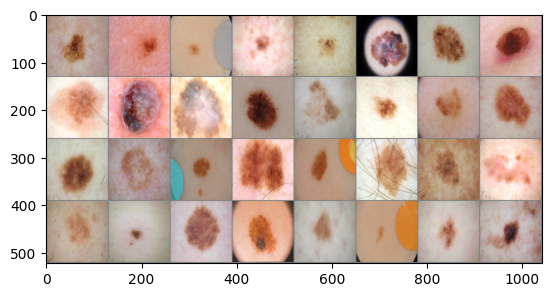

 benign malignant  benign  benign malignant  benign  benign malignant
malignant  benign  benign malignant  benign  benign malignant  benign
 benign  benign malignant  benign  benign malignant  benign  benign
 benign malignant  benign  benign malignant  benign  benign  benign


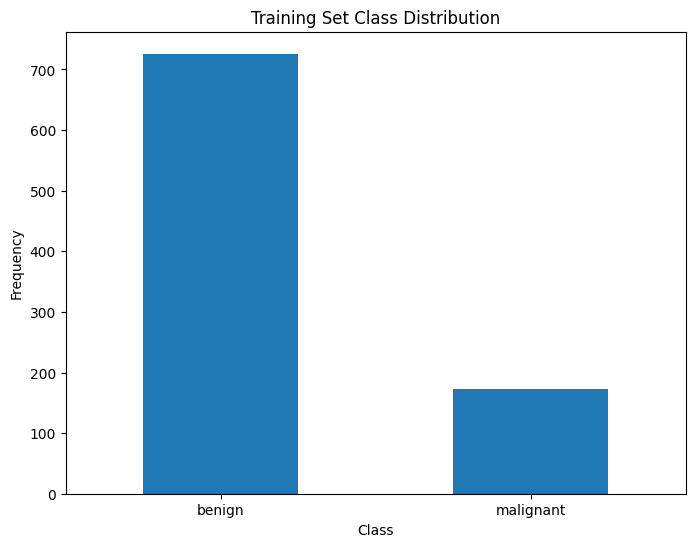

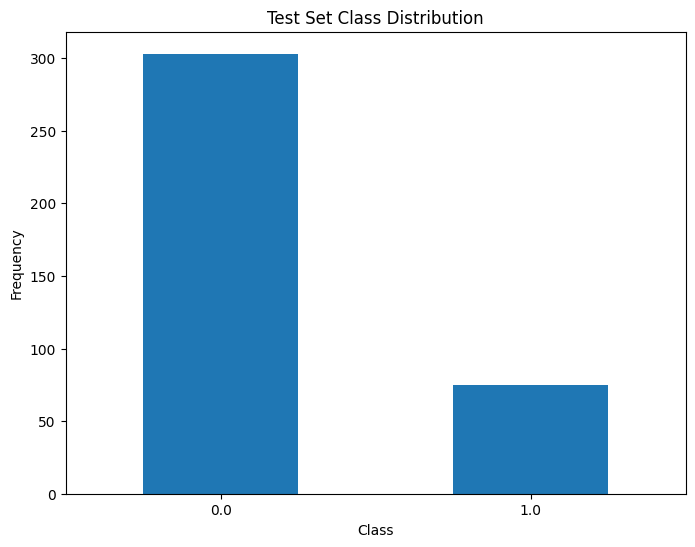

In [12]:
# ISIC Dataset EDA
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# 학습 데이터 로더에서 정규화를 되돌리고 이미지 시각화
def imshow(img):
  img = img / 2 + 0.5 # 정규화 복원
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

# 학습 데이터셋에서 샘플 이미지와 라벨 출력
dataiter = iter(tr_loader)
images, labels = next(dataiter)

# 이미지 시각화
imshow(torchvision.utils.make_grid(images))
for i in range(4):
  print(' '.join('%7s' % labels[j + (i+8)] for j in range(8)))

# EDA: 클래스 분포 확인
def plot_class_distribution(dataset, title='Class Distribution'):
  labels = [label for _, label in dataset]
  class_counts = pd.Series(labels).value_counts()

  plt.figure(figsize=(8, 6))
  class_counts.plot(kind='bar')
  plt.title(title)
  plt.xlabel('Class')
  plt.ylabel('Frequency')
  plt.xticks(rotation=0)
  plt.show()

# 학습 데이터셋 클래스 분포 시각화
plot_class_distribution(tr_ds, title='Training Set Class Distribution')

# 테스트 데이터셋 클래스 분포 시각화
plot_class_distribution(ts_ds, title='Test Set Class Distribution')

In [13]:
# 학습 장치 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device} device")

Using cpu device


In [15]:
# LeNet 신경망 모델 정의
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # input 3(RGB), output 6, kernel size 5x5 / 총 124개
        self.pool = nn.MaxPool2d(2, 2) # 풀링 : 2x2, maxpooling / 62개
        self.conv2 = nn.Conv2d(6, 16, 5) # input 6, output 16, kernel size 5x5 / 58(62-4)

        # 이미지 크기가 128x128 → conv2 이후 크기: 29x29
        self.fc1 = nn.Linear(16 * 29 * 29, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2) # 2개의 클래스로 분류

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        # print(x.shape)  # 텐서의 크기 확인 - 필요하다면 주석 해제하여 확인
        x = x.view(-1, 16 * 29 * 29)  # Flatten
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [16]:
# LeNet 학습 함수 정의
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, device='cpu'):
    # epoch 수 만큼 아래 내용을 반복
    for epoch in range(num_epochs):
      # 학습에 필요한 초기값 세팅
      model.train()
      running_loss = 0.0
      correct = 0
      total = 0 # 초기화

      # 1번의 batch 단위
      for inputs, labels in dataloader:
          # 이미지와 라벨을 gpu 메모리에 적재
          inputs, labels = inputs.to(device), labels.to(device)

          # 이전에 수행된 Back propagation 초기화
          optimizer.zero_grad()

          # 학습 진행
          outputs = model(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          # loss 값 계산
          running_loss += loss.item() * inputs.size(0)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      # 이번 epoch의 평균 loss 계산 및 출력
      epoch_loss = running_loss / len(dataloader.dataset)
      epoch_acc = correct / total

      print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')
      # 학습된 모델 반환
    return model

In [17]:
# LeNet 모델 학습
import torch.optim as optim
import torch
import cv2

class ISICDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)


    def __getitem__(self, index):
        img_name = os.path.join(self.root_dir, self.annotations.iloc[index, 0] + '.jpg')
        image = Image.open(img_name)
        label = 1 if self.annotations.iloc[index, 1] == 'malignant' else 0 # malignant와 benign을 정수로 변환

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


# 데이터셋 및 데이터로더 생성
tr_ds = ISICDataset(csv_file="/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_GroundTruth.csv",
                    root_dir="/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Training_Data",
                    transform=transform)

ts_ds = ISICDataset(csv_file="/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_GroundTruth.csv",
                    root_dir="/content/drive/MyDrive/ISIC2016/ISBI2016_ISIC_Part3_Test_Data", transform=transform)

tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
ts_loader = DataLoader(ts_ds, batch_size=32)

# 모델, 손실 함수, 옵티마이저 정의
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # learning rate가 0.001, 기본값으로 해도 됨

# 모델 학습
train_model(model, tr_loader, criterion, optimizer, num_epochs = 10, device = device)


Epoch 1/10, Loss: 0.5955, Accuracy: 0.7019
Epoch 2/10, Loss: 0.4934, Accuracy: 0.8076
Epoch 3/10, Loss: 0.4884, Accuracy: 0.8076
Epoch 4/10, Loss: 0.4778, Accuracy: 0.8087
Epoch 5/10, Loss: 0.4699, Accuracy: 0.8131
Epoch 6/10, Loss: 0.4612, Accuracy: 0.8120
Epoch 7/10, Loss: 0.4474, Accuracy: 0.8120
Epoch 8/10, Loss: 0.4407, Accuracy: 0.8165
Epoch 9/10, Loss: 0.4384, Accuracy: 0.8176
Epoch 10/10, Loss: 0.4399, Accuracy: 0.8198


LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=13456, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

In [18]:
# GPU로 할 떄 오류면 이걸로 하면됨
'''
# 모델 평가 함수
def evaluate_model(model, test_loader, device='cpu'):
    # 평가 모드로 전환
    model.eval()
    correct = 0
    total = 0
    # 그래디언트를 계산하지 않도록 설정
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # 장치로 이동
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    # 정확도 계산 및 반환
    accuracy = correct / total
    return accuracy

# 테스트 데이터셋을 사용하여 모델 평가
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
accuracy = evaluate_model(model, ts_loader, device=device)
print(f'Test Accuracy: {accuracy * 100:.2f}%')
'''


"\n# 모델 평가 함수\ndef evaluate_model(model, test_loader, device='cpu'):\n    # 평가 모드로 전환\n    model.eval()\n    correct = 0\n    total = 0\n    # 그래디언트를 계산하지 않도록 설정\n    with torch.no_grad():\n        for images, labels in test_loader:\n            images, labels = images.to(device), labels.to(device)  # 장치로 이동\n            outputs = model(images)\n            _, predicted = torch.max(outputs.data, 1)\n            total += labels.size(0)\n            correct += (predicted == labels).sum().item()\n    # 정확도 계산 및 반환\n    accuracy = correct / total\n    return accuracy\n\n# 테스트 데이터셋을 사용하여 모델 평가\ndevice = torch.device('cuda' if torch.cuda.is_available() else 'cpu')\naccuracy = evaluate_model(model, ts_loader, device=device)\nprint(f'Test Accuracy: {accuracy * 100:.2f}%')\n"

In [19]:
# 모델 저장 (학습이 완료된 후)
model_save_path = '/content/drive/MyDrive/ISIC2016/lenet_isic2016.pth'
torch.save(model.state_dict(), model_save_path)
print(f"모델이 저장되었습니다: {model_save_path}")

모델이 저장되었습니다: /content/drive/MyDrive/ISIC2016/lenet_isic2016.pth


In [22]:
# # 저장된 모델 불러오기 (추론이나 재학습 시 사용)
loaded_model = LeNet().to(device)
loaded_model.load_state_dict(torch.load(model_save_path))
loaded_model.eval()  # 평가 모드로 전환


LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=13456, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

In [23]:
# 테스트 데이터로 모델 정확도 평가
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()  # 평가 모드
    correct = 0
    total = 0

    with torch.no_grad():  # 평가 시에는 gradient 계산을 꺼줌
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"테스트 데이터 정확도: {accuracy:.4f}")

# 평가 실행
evaluate_model(loaded_model, ts_loader, device=device)


테스트 데이터 정확도: 0.9418
